In [ ]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh
import matplotlib as mpl
 
# additional Hermes-3 post processing tools (https://github.com/mikekryjak/sdtools)
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))


from heatflux_functions import * 

from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 10



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:

def replace_guards(var):
    """
	This in-place replaces the points in the guard cells with the points on the boundary
    
    """
    # Strip the edge guard cells
    var = var[1:-1]

    var[0] = 0.5*(var[0] + var[1])
    var[-1] = 0.5*(var[-1] + var[-2])
    return var

In [21]:
def spitzer_q(dataframe):
    
    x = dataframe['y']
    Te = dataframe['Te']
    Ti = dataframe['Td+']
    Ne = dataframe['Ne']
    Ni = dataframe['Nd+']
    kappa_e = dataframe['kappa_par_e']
    kappa_i = dataframe['kappa_par_d+']

    # print(kappa_e)

    grad_T = np.gradient(Te, x)
    q = -kappa_e * grad_T

    return q

    import scipy.integrate

def divq_integrate(dataframe, snb_int = False):
    """
    Calculate the total heat flux from the divergence of the Spitzer-Harm fluxes.
    If snb == True outputs integral of divq_snb, otherwise outputs integral of divq_sh.
    """

    x = np.ravel(dataframe['y'].values)[1:-1]
    Te = np.ravel(dataframe['Te'].values)


    div_q_snb = replace_guards(np.ravel(dataframe['Div_Q_SNB'].values))
   
    print('x =' , len(x))
    print('div_q_snb = ' , len(div_q_snb))

    q_snb = scipy.integrate.cumulative_trapezoid(div_q_snb, x, initial=0)

    return q_snb

# I/O

In [22]:

alpha_vals = [-1, 0.2, 0.06, 'snb']
neon_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
parent_dir = '/Users/lloyd/Documents/hermes_dir/flux_limiter_detachment/Long_runs'

cs = dict()


for alpha in alpha_vals:
    for neon in neon_vals:
        name = f"alpha_{alpha}_neon_{neon}"
        print(f"Loading {name}")
        cs[name] = Load.case_1D(f'{parent_dir}/alpha_{alpha}/neon_{neon}', guard_replace = False, use_squash=True)


Loading alpha_-1_neon_0.0
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:13:42, dmp file date 04/19/2025, 00:54:56
Loading alpha_-1_neon_0.01
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:13:54, dmp file date 04/19/2025, 04:33:05
Loading alpha_-1_neon_0.02
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:14:06, dmp file date 04/19/2025, 07:06:33
Loading alpha_-1_neon_0.03
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:14:18, dmp file date 04/19/2025, 08:45:03
Loading alpha_-1_neon_0.04
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:14:31, dmp file date 04/19/2025, 09:19:16
Loading alpha_-1_neon_0.05
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:14:43, dmp file date 04/19/2025, 09:53:41
Loading alpha_-1_neon_0.06
- Looking for squash file
- Squash file found. squash date 04/20/2025, 15:14:56, dmp file date 04/19/2025, 10:25:17


# Profiles Te, q_parallel_e, Ne, Nd Fig 2./8.

2 2
x = 802
div_q_snb =  802


/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_67132/2620999057.py:263: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])  # Make space for the legend


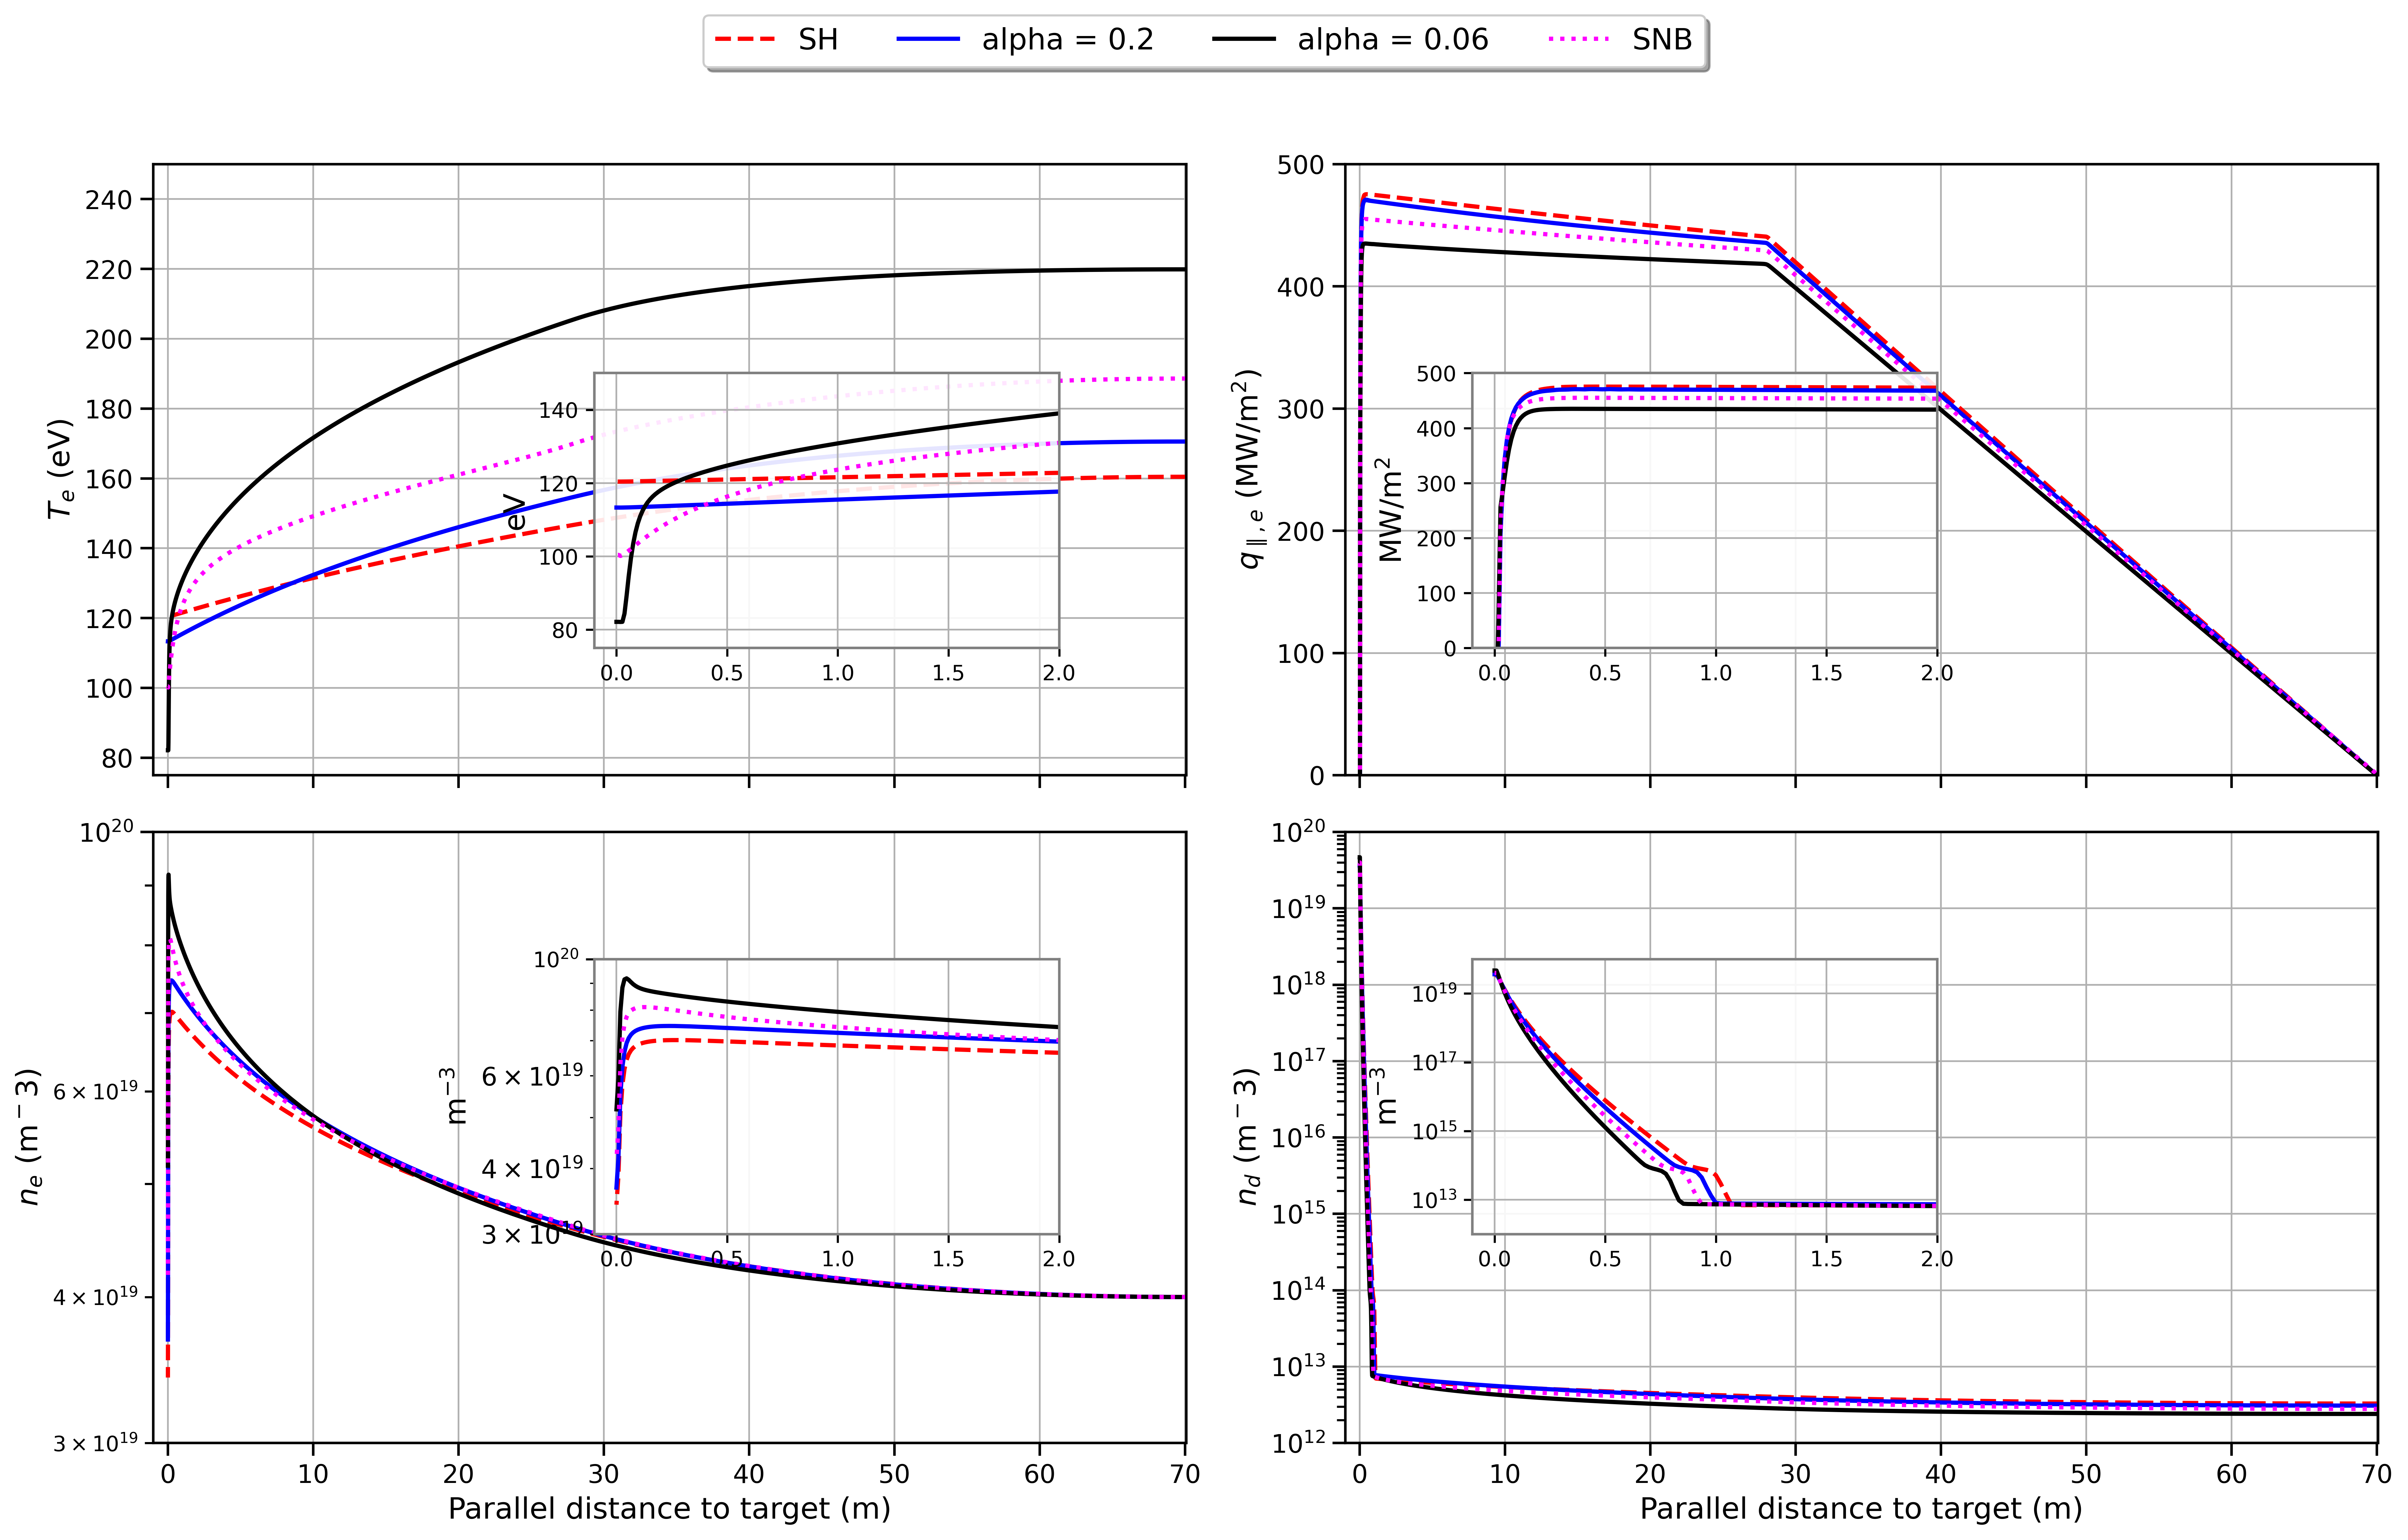

In [40]:
params = ['Te',  'q_cond', 'Ne', 'Nd']

# params = ['Rneon']

neon_value = '0.0'
# params = ['Te']

# EASY OPTION TO CHANGE INSET X-AXIS SCALE
INSET_XSCALE = 'linear'  # Change this to 'linear' or 'log' as needed

# Set global font sizes
plt.rcParams.update({
    'font.size': 14,           # Default font size
    'axes.titlesize': 16,      # Subplot titles
    'axes.labelsize': 14,      # Axis labels
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
    'legend.fontsize': 12,     # Legend text
    'figure.titlesize': 18     # Main figure title
})

ncols = max(round(len(params)/2), 1)
nrows = ncols

print(ncols, nrows)

fig, ax = plt.subplots(nrows, ncols, figsize=(16, 10), dpi=500, sharex=True)  # Increased figure size

if isinstance(ax, np.ndarray):  # When multiple subplots
    ax = ax.flatten()  # Flatten the 2D array of axes to 1D
else:  # When there is only one subplot
    ax = np.array([ax])  # Make it a 1D array for consistency

y = cs['alpha_-1_neon_0.0'].ds['y'].values[1:-1]
y_flipped = (y.max() - y) 

# Create inset axes for each subplot with custom positioning
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Define positions: top row (lower right, lower left), bottom row (upper right, upper left)
inset_positions = ['lower right', 'lower left', 'upper right', 'upper left']

inset_axes_list = []
for i, axes in enumerate(ax):
    pos = inset_positions[i % len(inset_positions)]
    
    # Create inset with positioning closer to center using borderpad
    inset_ax = inset_axes(axes, width='45%', height='45%', loc=pos,
                         borderpad=5)  # borderpad moves inset away from edge
    
    # Customize inset appearance
    inset_ax.patch.set_facecolor('white')
    inset_ax.patch.set_alpha(0.9)
    
    # Add subtle border
    for spine in inset_ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('gray')
    
    inset_axes_list.append(inset_ax)

# y_flipped = y

for i in alpha_vals:
    label = i
    if i == -1:
        linestyle = '--'
        color = 'red'
        label = 'SH'
    elif i == 0.2:
        linestyle = '-'
        color = 'blue'
        label = 'alpha = 0.2'
    elif i == 0.06:
        linestyle = '-'
        color = 'black'
        label = 'alpha = 0.06'
    elif i == 'snb':
        linestyle = ':'
        color = 'magenta'
        label = 'SNB'
    

    for j, value in enumerate(params):

        if value == 'q_cond':
            if i == 'snb':
                profile = divq_integrate(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1), snb_int=True)
            else:
                profile = replace_guards(spitzer_q(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)))
            
            # Main plot
            ax[j].plot(y_flipped[1:-1], profile[1:-1] * 1e-6, linestyle=linestyle, color=color, label=f'{label}', linewidth=2)
            # Inset plot with configurable x-axis scale
            inset_axes_list[j].plot(y_flipped[1:-1], profile[1:-1] * 1e-6, linestyle=linestyle, color=color, linewidth=2)
            inset_axes_list[j].set_xscale(INSET_XSCALE)
            
            if np.max(profile) > 1e3:
                # ax[j].set_yscale('log')
                ax[j].set_ylabel(r'$q_{\parallel, e}$ (MW/m$^2$)', fontsize=14)
                # ax[j].set_xlabel('$S_{\parallel}$ (m)')
            ax[j].set_ybound(0, 500)
            inset_axes_list[j].set_ybound(0, 500)
            inset_axes_list[j].set_ylabel('MW/m$^2$')

        elif value == 'Rneon':
            profile = -1 * replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)[value].values) * replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)['dv'].values)
            profile_Rd = -1 * replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)['Rd+_ex'].values) * replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)['dv'].values)
            
            # Main plot
            ax[j].plot(y_flipped[1:-1], profile[1:-1], linestyle=linestyle, color=color, label=f'{label}', linewidth=2)
            # Inset plot with configurable x-axis scale
            inset_axes_list[j].plot(y_flipped[1:-1], profile[1:-1], linestyle=linestyle, color=color, linewidth=2)
            inset_axes_list[j].set_xscale(INSET_XSCALE)
            
            # ax[j].plot(y[::-1][1:-1], profile_Rd[1:-1], linestyle=linestyle, color=color, label=f'alpha={label}')

            # if np.max(profile) > 1e3:
            #     # ax[j].set_yscale('symlog')
            # ax[j].set_xlabel('$S_{\parallel}$ (m)')
            units = cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)[value].units
            ax[j].set_ylabel(f'Neon radiation (W)', fontsize=14)
            inset_axes_list[j].set_ylabel('W')

        # elif value == 'Vd+':
        #     profile = replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)[value].values) * replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)['Nd+'].values)
        #     ax[j].plot(y[::-1], profile, linestyle=linestyle, color=color, label=f'alpha={label}')
        #     # if np.max(profile) > 1e3:
        #         # ax[j].set_yscale('symlog')
        #     ax[j].set_xlabel('$S_{\parallel}$ (m)')
        #     units = cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)[value].units
        #     ax[j].set_ylabel(f'Ion flux to target ({units})')

        elif value == 'Ne':
            profile = replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)[value].values)
            
            # Main plot
            ax[j].plot(y_flipped, profile, linestyle=linestyle, color=color, label=f'{label}', linewidth=2)
            # Inset plot with configurable x-axis scale
            inset_axes_list[j].plot(y_flipped, profile, linestyle=linestyle, color=color, linewidth=2)
            inset_axes_list[j].set_xscale(INSET_XSCALE)
            inset_axes_list[j].set_ylabel(units)
            
            if np.max(profile) > 1e3:
                ax[j].set_yscale('log')
                inset_axes_list[j].set_yscale('log')
            # ax[j].set_xlabel('$S_{\parallel}$ (m)')
            units = cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)[value].units
            label = r'$n_e$'
            ax[j].set_ylabel(f'{label} (m$^{-3}$)', fontsize=14)
            ax[j].set_ybound(3e19, 1e20)
            inset_axes_list[j].set_ybound(3e19, 1e20)
            inset_axes_list[j].set_ylabel(r'm$^{-3}$')

        elif value == 'Nd':
            profile = replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)[value].values)
            
            # Main plot
            ax[j].plot(y_flipped, profile, linestyle=linestyle, color=color, label=f'{label}', linewidth=2)
            # Inset plot with configurable x-axis scale
            inset_axes_list[j].plot(y_flipped, profile, linestyle=linestyle, color=color, linewidth=2)
            inset_axes_list[j].set_xscale(INSET_XSCALE)

            
            if np.max(profile) > 1e3:
                ax[j].set_yscale('log')
                inset_axes_list[j].set_yscale('log')
            # ax[j].set_xlabel('$S_{\parallel}$ (m)')
            units = cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)[value].units
            label = r'$n_d$'
            ax[j].set_ylabel(f'{label} (m$^{-3}$)', fontsize=14)
            ax[j].set_ybound(1e12, 1e20)
            inset_axes_list[j].set_ybound(1e12, 1e20)
            inset_axes_list[j].set_ylabel(r'm$^{-3}$')

        elif value == 'Te':
            profile = replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)[value].values)
            
            # Main plot
            ax[j].plot(y_flipped, profile, linestyle=linestyle, color=color, label=f'{label}', linewidth=2)
            # Inset plot with configurable x-axis scale
            inset_axes_list[j].plot(y_flipped, profile, linestyle=linestyle, color=color, linewidth=2)
            inset_axes_list[j].set_xscale(INSET_XSCALE)

            
            if np.max(profile) > 1e3:
                ax[j].set_yscale('log')
                inset_axes_list[j].set_yscale('log')
            # ax[j].set_xlabel('$S_{\parallel}$ (m)')
            units = cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)[value].units
            ax[j].set_ylabel(r'$T_e$ (eV)', fontsize=14)
            ax[j].set_ybound(75, 250)
            inset_axes_list[j].set_ybound(75, 150)
            inset_axes_list[j].set_ylabel(r'eV')

            
        else:
            profile = replace_guards(cs[f'alpha_{i}_neon_{neon_value}'].ds.isel(t=-1)[value].values)
            
            # Main plot
            ax[j].plot(y_flipped, profile, linestyle=linestyle, color=color, label=f'{label}', linewidth=2)
            # Inset plot with configurable x-axis scale
            inset_axes_list[j].plot(y_flipped, profile, linestyle=linestyle, color=color, linewidth=2)
            inset_axes_list[j].set_xscale(INSET_XSCALE)
            # inset_axes_list[j].set_ylabel(label)

            if np.max(profile) > 1e3:
                ax[j].set_yscale('symlog')
                inset_axes_list[j].set_yscale('symlog')
            # ax[j].set_xlabel('$S_{\parallel}$ (m)')
            units = cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)[value].units
            ax[j].set_ylabel(f'{value} ({units})', fontsize=14)

            
# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.5, wspace=0.5)  # Increased spacing for larger fonts

for axes in ax:
    axes.set_xscale('linear')
    # Set tick parameters for main axes
    axes.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6)
    axes.tick_params(axis='both', which='minor', labelsize=10, width=1, length=4)
    # Make axis lines thicker
    for spine in axes.spines.values():
        spine.set_linewidth(1.2)

# Set x-axis labels with larger font
ax[2].set_xlabel('Parallel distance to target (m)', fontsize=14)
ax[3].set_xlabel('Parallel distance to target (m)', fontsize=14)

for axes in ax:
    axes.set_xbound(-1,70.1)

# Set x-bounds for inset plots and format them
for inset_ax in inset_axes_list:
    if INSET_XSCALE == 'log':
        # Filter out non-positive values for log scale
        x_min = max(0.1, np.min(y_flipped[y_flipped > 0]))  # Start from 0.1 or smallest positive value
        x_max = np.max(y_flipped)
        inset_ax.set_xbound(x_min, x_max)
    else:  # linear scale
        inset_ax.set_xbound(-0.1, 2)  # Same as main plots
    
    # Set tick parameters for inset plots
    inset_ax.tick_params(labelsize=10, width=1, length=4)
    # Make inset axis lines slightly thicker
    for spine in inset_ax.spines.values():
        spine.set_linewidth(1.2)

# Only get legend handles/labels from the first axis (assumes same labels on all)
handles, labels = ax[0].get_legend_handles_labels()

# Create a single legend for the entire figure with larger font
fig.legend(handles, labels, loc='upper center', ncol=len(labels), 
          bbox_to_anchor=(0.5, 1.02), fontsize=14, frameon=True, 
          fancybox=True, shadow=True)
fig.subplots_adjust(top=0.80, hspace=0.5, wspace=0.5)  # Adjusted for larger fonts and spacing

# Set the title for the entire figure
# fig.suptitle(f'Neon concentration = {neon_value}', fontsize=18)

# Final layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.94])  # Make space for the legend

# Target Temperature vs Neon Fig 3. 

Loading -1 0.0
Loading -1 0.01
Loading -1 0.02
Loading -1 0.03
Loading -1 0.04
Loading -1 0.05
Loading -1 0.06
Loading -1 0.07
Loading -1 0.08
Loading -1 0.09
Loading -1 0.1
Loading 0.2 0.0
Loading 0.2 0.01
Loading 0.2 0.02
Loading 0.2 0.03
Loading 0.2 0.04
Loading 0.2 0.05
Loading 0.2 0.06
Loading 0.2 0.07
Loading 0.2 0.08
Loading 0.2 0.09
Loading 0.2 0.1
Loading 0.06 0.0
Loading 0.06 0.01
Loading 0.06 0.02
Loading 0.06 0.03
Loading 0.06 0.04
Loading 0.06 0.05
Loading 0.06 0.06
Loading 0.06 0.07
Loading 0.06 0.08
Loading 0.06 0.09
Loading 0.06 0.1
Loading snb 0.0
Loading snb 0.01
Loading snb 0.02
Loading snb 0.03
Loading snb 0.04
Loading snb 0.05
Loading snb 0.06
Loading snb 0.07
Loading snb 0.08
Loading snb 0.09
Loading snb 0.1


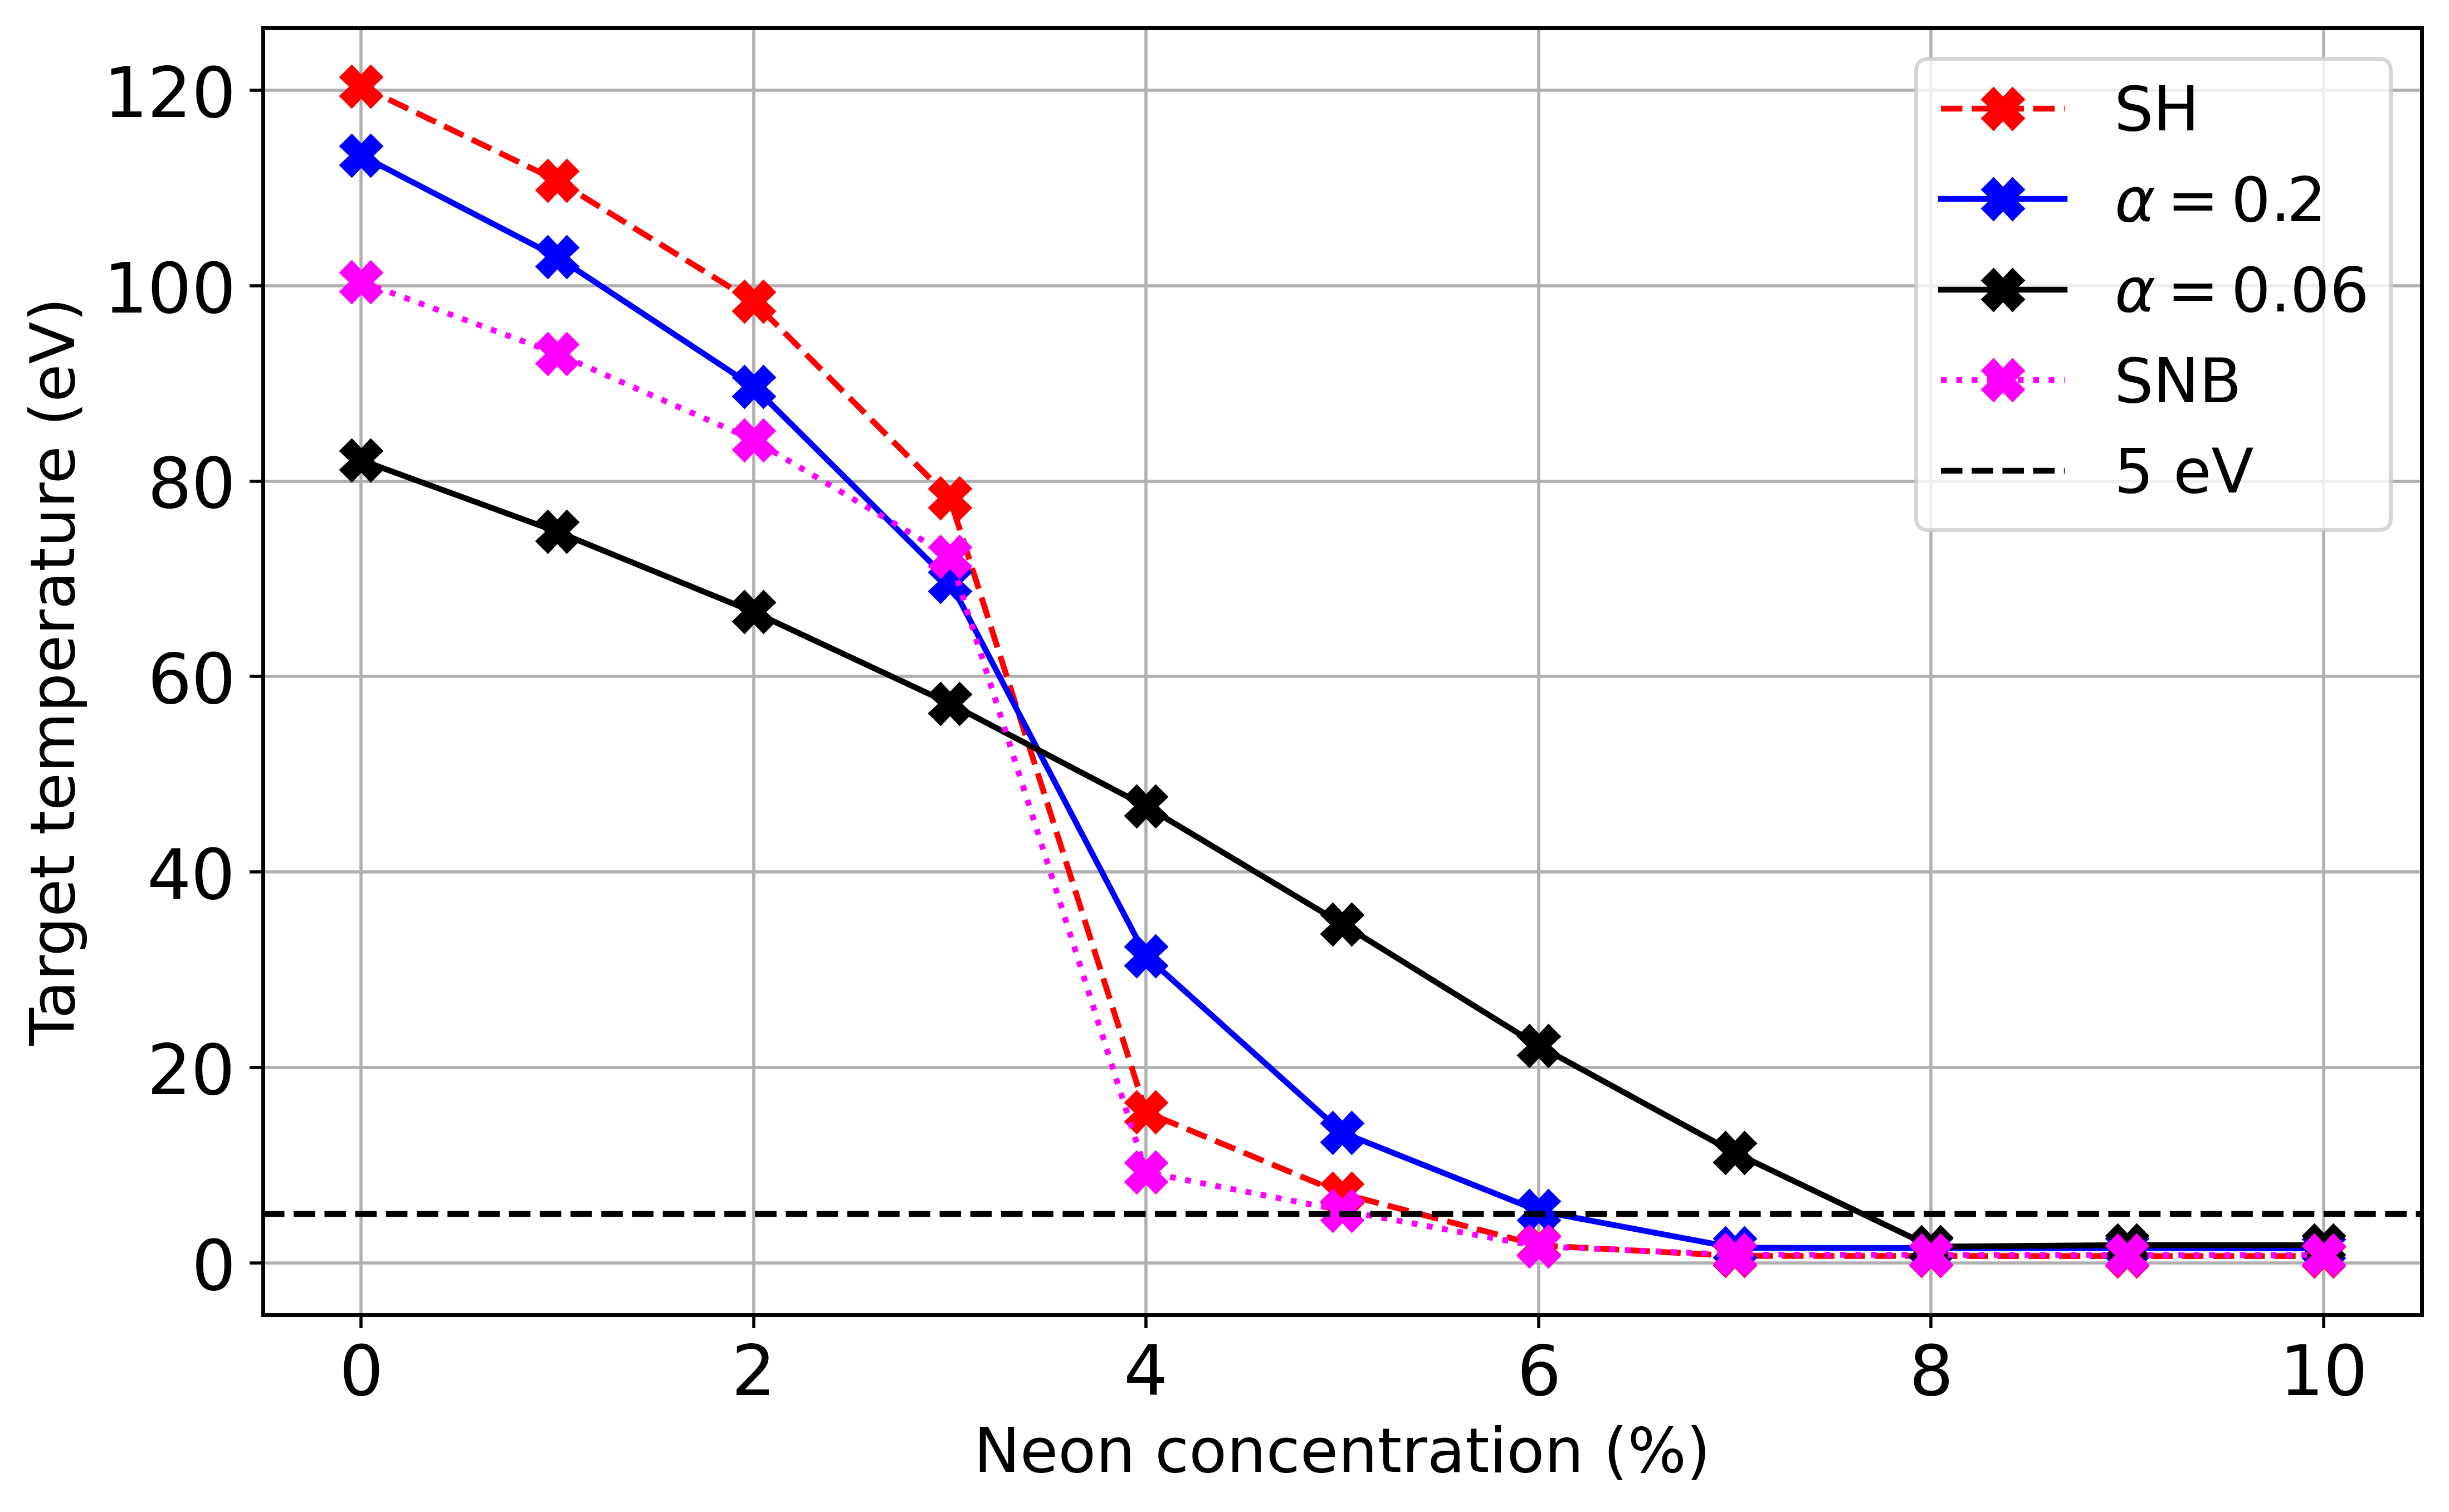

In [23]:
fig,ax = plt.subplots(1, 1, figsize=(10, 6), dpi=500)
# ax2 = ax.twinx()


neon_vals = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
neon_vals = np.array(neon_vals)

for i in alpha_vals:
    target_temp_list = []
    upstream_temp_list = []
    neon_radiation_list = []
    if i == -1:
        linestyle = '--'
        color = 'red'
        label = 'SH'
    elif i == 0.2:
        linestyle = '-'
        color = 'blue'
        label = r'$\alpha = 0.2$'
    elif i == 0.06:
        linestyle = '-'
        color = 'black'
        label = r'$\alpha = 0.06$'
    elif i == 'snb':
        linestyle = ':'
        color = 'magenta'
        label = 'SNB'

    for j in neon_vals:
        print(f"Loading {i} {j}")
        target_temp = replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['Te'].values)[-1]
        target_temp_list.append(target_temp)
        upstream_temp = replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['Te'].values)[3]
        upstream_temp_list.append(upstream_temp)
        neon_radiation = -1 * sum(replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['Rneon'].values) * replace_guards(cs[f'alpha_{i}_neon_{j}'].ds.isel(t=-1)['dv'].values))
        neon_radiation_list.append(neon_radiation)

    ax.plot(np.array(neon_vals)*100, target_temp_list, linestyle=linestyle, color=color, label=f'{label}', markersize=10, marker = 'X')
    # ax2.plot(np.array(neon_vals)*100, upstream_temp_list, linestyle=linestyle, color=color, markersize=markersize, marker = 'o')
    # ax2.plot(np.array(neon_vals)*100, neon_radiation_list, linestyle=linestyle, color=color, markersize=markersize, marker = 'o')

    
ax.axhline(5, color='black', linestyle='--', label='5 eV')
ax.set_xlabel('Neon concentration (%)')
ax.set_ylabel('Target temperature (eV)')
# ax2.set_ylabel('Upstream temperature (eV)')
ax.legend()



# ADAS neon radiation cooling curve Fig 4.

88
44.04404404404405


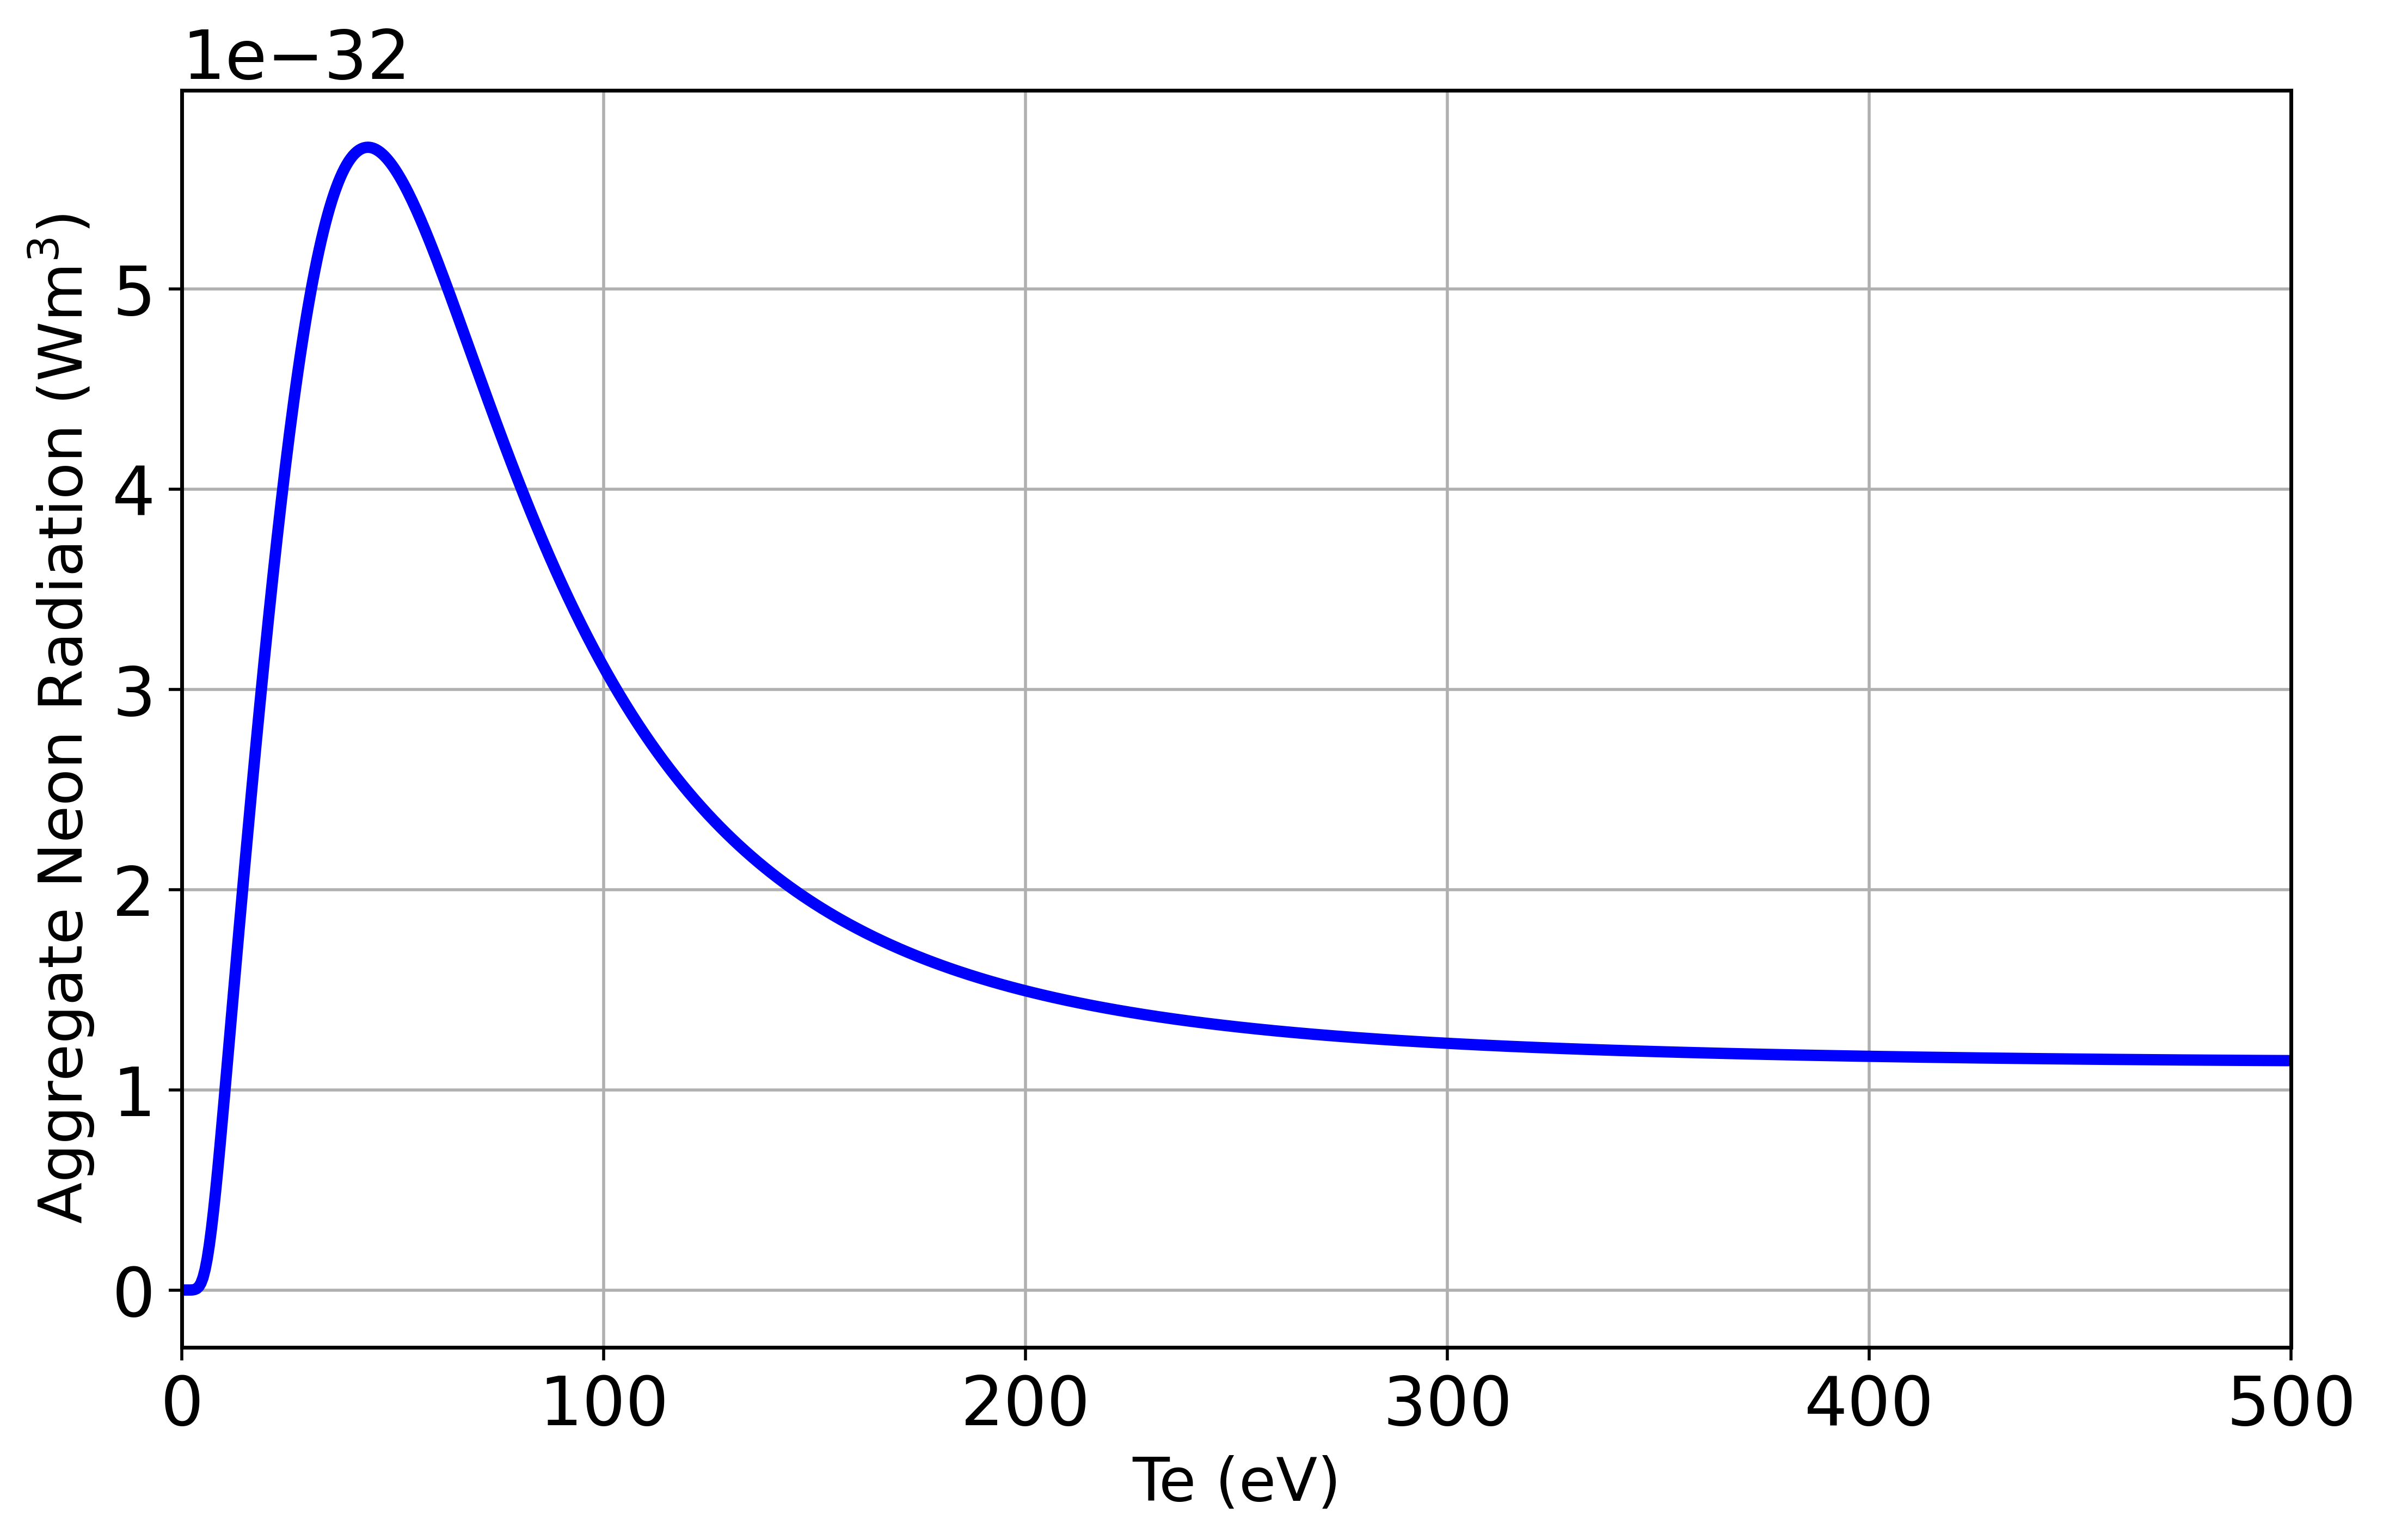

In [27]:
import numpy as np

def neon_adas_curve(Te):
    logT = np.log(Te)
    log_out = np.zeros_like(Te)

    # Coefficients for the polynomial part
    coefficients = np.array([
        -8.21475117e+01, 1.28929854e+01, -4.74266289e+01,
         7.45222324e+01, -5.75710722e+01, 2.57375965e+01,
        -7.12758563e+00, 1.24287546e+00, -1.32943407e-01,
         7.97368445e-03, -2.05487897e-04
    ])

    # Valid temperature range for the polynomial
    valid_mask = (Te >= 2) & (Te <= 1000)
    below_mask = Te < 2
    above_mask = Te > 1000

    # Apply the polynomial coefficients
    for i, coeff in enumerate(coefficients):
        log_out[valid_mask] += coeff * logT[valid_mask] ** i
    
    # Apply the exponential to the valid range
    log_out[valid_mask] = np.exp(log_out[valid_mask])
    
    # Assign the constant values outside the valid temperature range
    log_out[below_mask] = 6.35304113e-36
    log_out[above_mask] = 1.17894628e-32

    return log_out

# Example usage with an array of temperatures:
Te_array = np.array([1.0, 5.0, 10.0, 100.0, 500.0, 1500.0])
output_values = neon_adas_curve(Te_array)
# print(output_values)


# Use this updated Neon_adas class to create the color map and overlay it onto the plot

Te = np.linspace(0, 500, 1000)  # Example temperature value
result = neon_adas_curve(Te)

fig,axis = plt.subplots(1, 1, figsize=(10, 6), dpi = 500)
# axis2 = axis.twinx()


max_index = np.argmax(result)
print(max_index)

print(Te[max_index])

axis.plot(Te, result, label='Neon ADAS Curve', linewidth=linewidth, color = 'blue')
# axis.axvspan(100, 200, color='darkgreen', alpha=0.3)  # Red color with transparency
# axis.axvspan(12.5, 100, color='limegreen', alpha=0.3)  # Red color with transparency
# axis.axvspan(200, 500, color='darkred', alpha=0.3)  # Red color with transparency
# axis.axvspan(0, 12.5, color='red', alpha=0.3)  # Red color with transparency

# for i in alpha_vals:

#     if i == -1:
#         linestyle = '--'
#         color = 'red'
#     elif i == 0.2:
#         linestyle = '-'
#         color = 'blue'
#     elif i == 0.06:
#         linestyle = '-'
#         color = 'black'
#     elif i == 'snb':
#         linestyle = ':'?
#         color = 'magenta'
#     axis2.plot(replace_guards(cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)['Te'].values), replace_guards(cs[f'alpha_{i}_neon_0.0'].ds.isel(t=-1)['Ne'].values), label=f'alpha = {i}', linewidth=linewidth)
# axis2.set_ylabel(r'Electron density (m$^{-3}$)')
# axis2.legend(loc='upper right')
    
axis.set_xlabel('Te (eV)')
axis.set_ylabel(r'Aggregate Neon Radiation (Wm$^{3}$)')
axis.set_xbound(0, 500)
# axis.set_yscale('log')
# axis.set_xbound(0,200)

# profiles colour map Fig 5. 

neon =  0.03


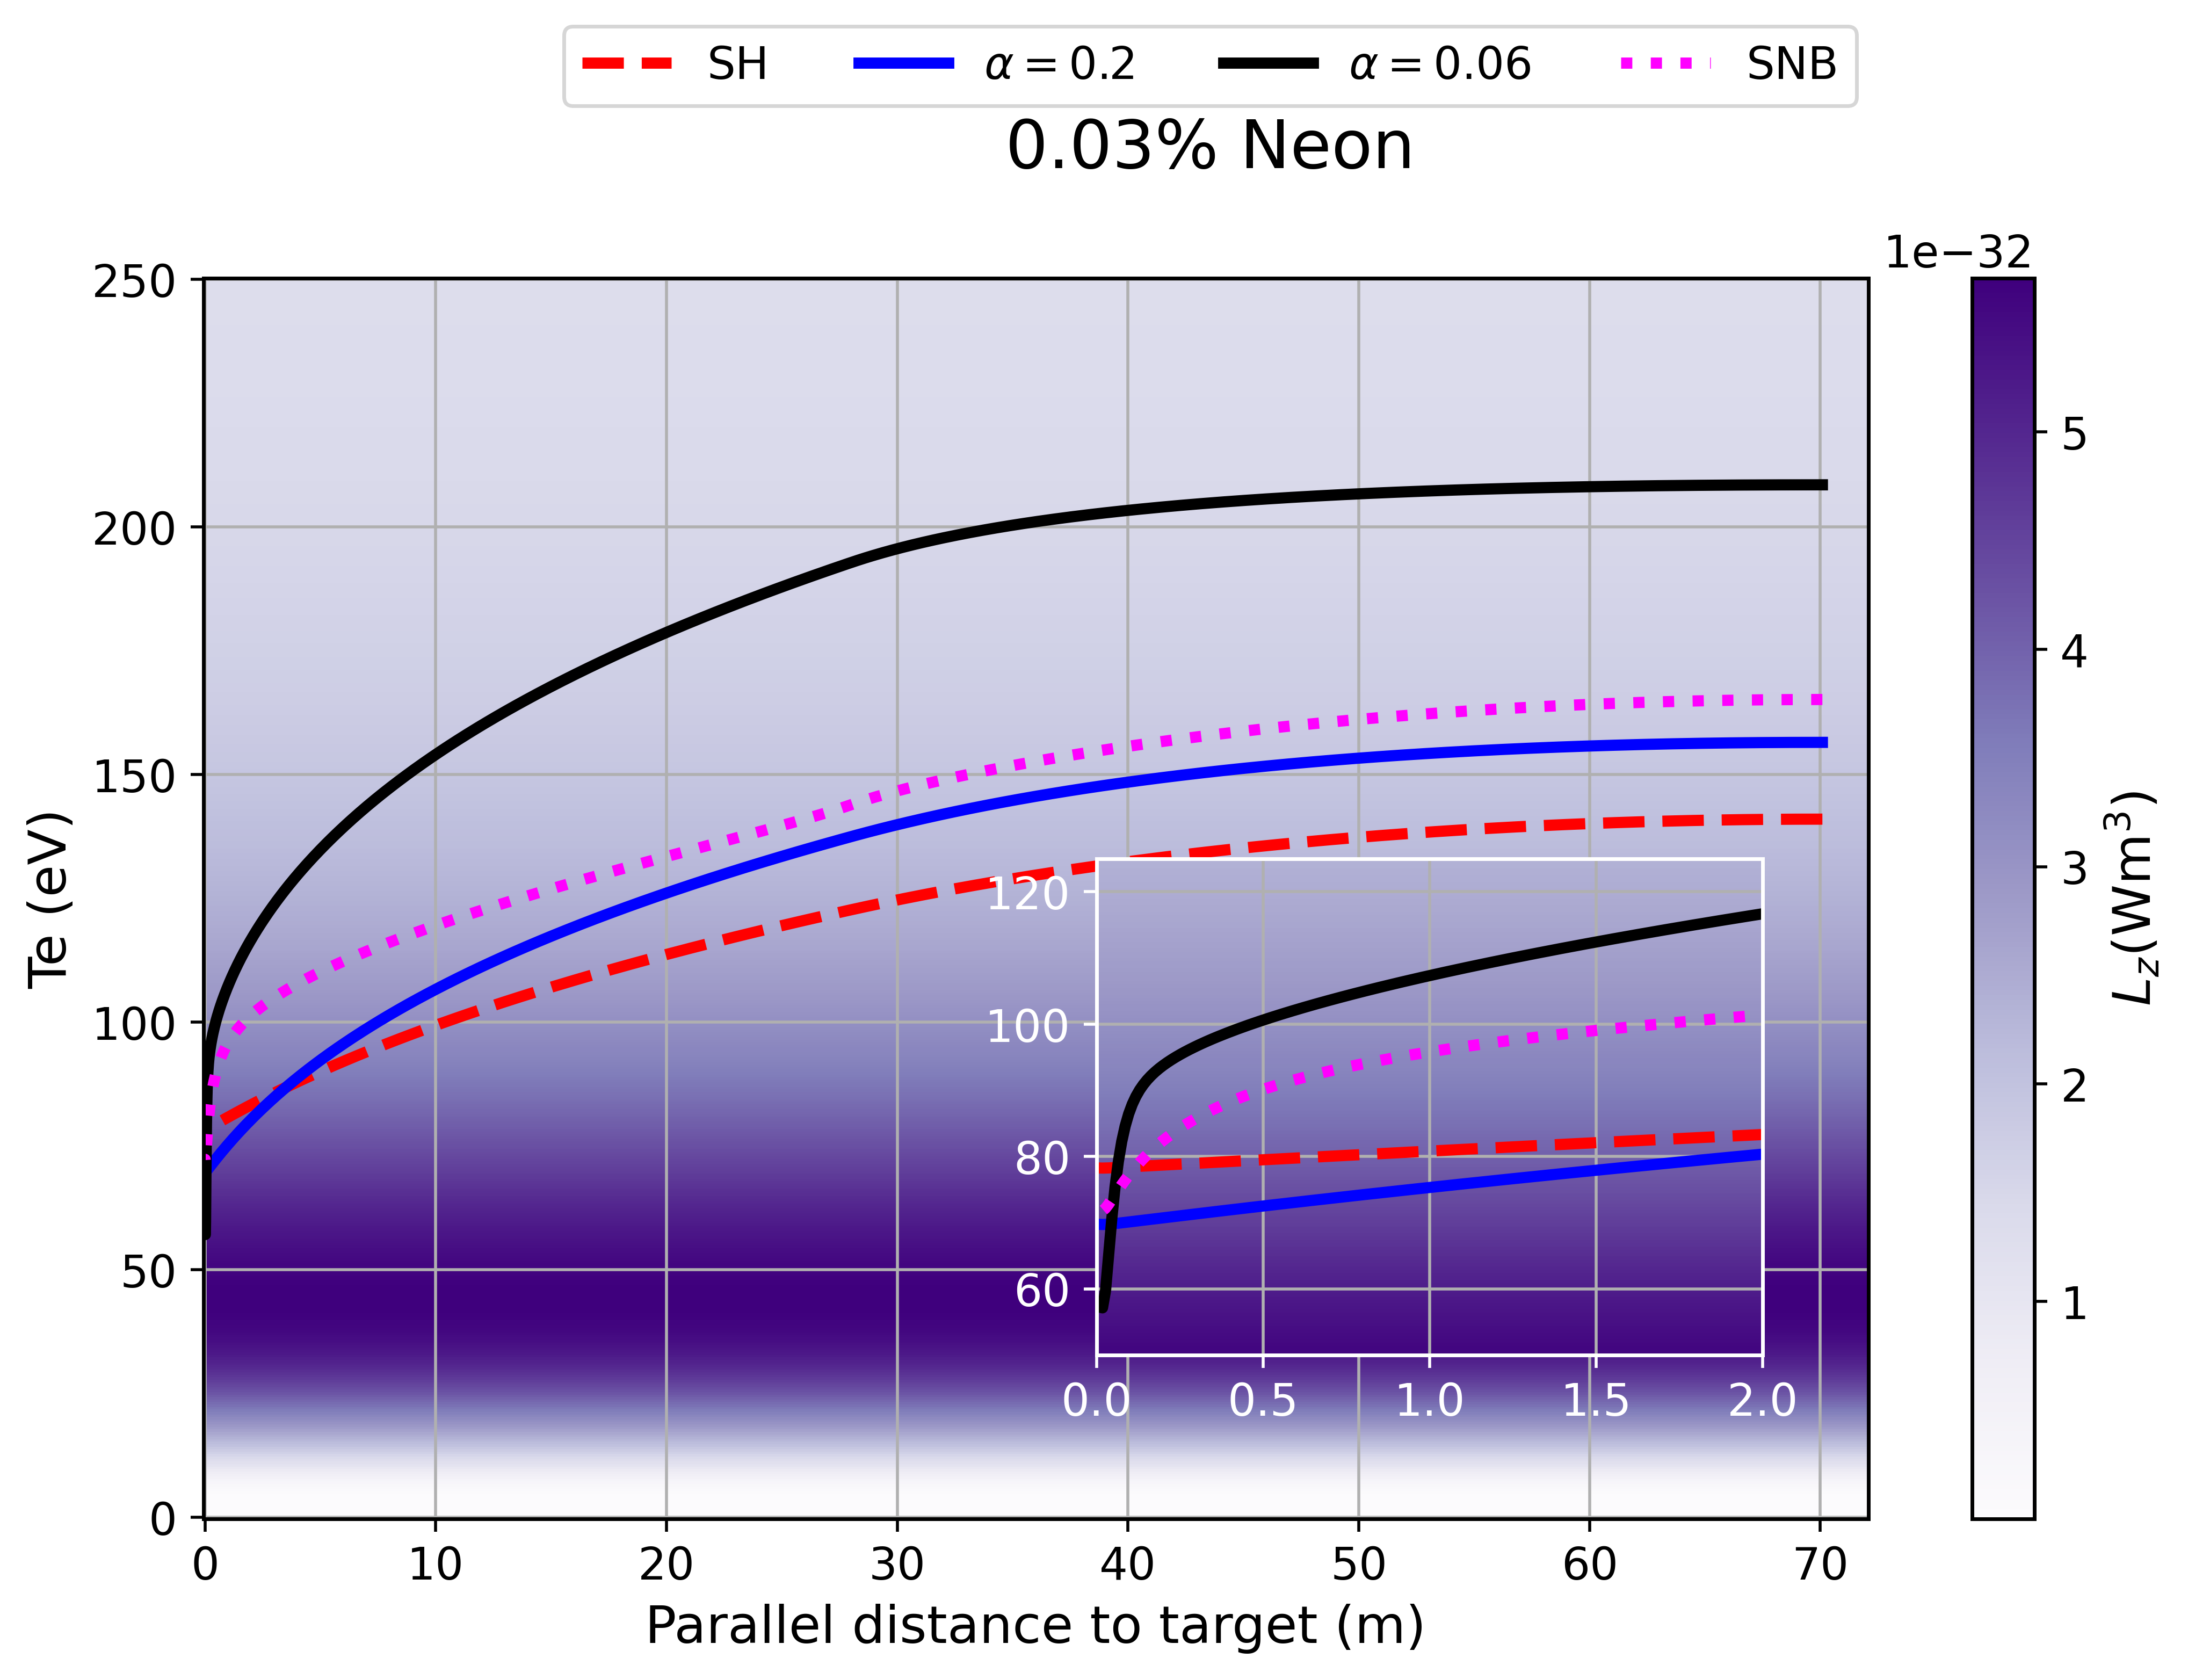

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

neon_vals = np.array([0.03])
for k in neon_vals:
    plt.close()
    # Plot the colormap
    fig,ax = plt.subplots(nrows=1,ncols=1, figsize=(10, 6), dpi = 500)
    
    # Create inset axes in bottom right corner
    ax_inset = inset_axes(ax, width="80%", height="80%", 
                         bbox_to_anchor=(0.45, 0.05, 0.5, 0.5),
                         bbox_transform=ax.transAxes)
    
    S_II = np.linspace(0, 72, 500)  # Spatial coordinate
    T_e = np.linspace(0, 250, 500)  # Electron temperature
    # Create a meshgrid for S_II and T_e
    S_II_grid, T_e_grid = np.meshgrid(S_II, T_e)
    # Evaluate the curve function on the meshgrid
    Z = neon_adas_curve(T_e_grid)
    cmap = 'Purples'
    norm = Normalize(vmin=np.min(Z), vmax=np.max(Z))
    ax.pcolormesh(S_II_grid, T_e_grid, Z, shading='auto', norm=norm, cmap=cmap)
    ax_inset.pcolormesh(S_II_grid, T_e_grid, Z, shading='auto', norm=norm, cmap=cmap)
    fig.colorbar(label=r'$L_z$(Wm$^{3}$)', mappable=ax.collections[0])
    S_II = np.linspace(64, 72, 500)  # Spatial coordinate
    T_e = np.linspace(0, 250, 500)  # Electron temperature
    # Create a meshgrid for S_II and T_e
    S_II_grid, T_e_grid = np.meshgrid(S_II, T_e)
    Z = neon_adas_curve(T_e_grid)
    norm = Normalize(vmin=np.min(Z), vmax=np.max(Z))
    y = cs[f'alpha_-1_neon_{k}'].ds['y'].values[1:-1]
    y_flipped = (np.max(y) - y)
    
    print('neon = ', k)
    alpha_vals = [-1, 0.2, 0.06, 'snb']
    for i in alpha_vals:
        if i == -1:
            linestyle = '--'
            color = 'red'
            label = 'SH'
        elif i == 0.2:
            linestyle = '-'
            color = 'blue'
            label = r'$\alpha = 0.2$'
        elif i == 0.06:
            linestyle = '-'
            color = 'black'
            label = r'$\alpha = 0.06$'
        elif i == 'snb':
            linestyle = ':'
            color = 'magenta'
            label = 'SNB'
            
        profile = replace_guards(cs[f'alpha_{i}_neon_{k}'].ds.isel(t=-1)['Te'].values)
        ax.plot(y_flipped, profile, linestyle=linestyle, color=color, label=f'{label}', linewidth=linewidth)
        ax_inset.plot(y_flipped, profile, linestyle=linestyle, color=color, linewidth=linewidth)
    # Get handles and labels
    handles, labels = plt.gca().get_legend_handles_labels()
    handles, labels = ax.get_legend_handles_labels()
    # Create a single legend for the entire figure
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05))
    # Set labels and title as needed
    ax.set_ylabel(r'Te (eV)')
    ax.set_xlabel(r'Parallel distance to target (m)')
    
    # Set inset axes to log scale on x-axis
    # ax_inset.set_xscale('log')
    ax_inset.set_xbound(0,2)
    ax_inset.set_ybound(50, 125)
    fig.suptitle(f'{k}% Neon')
    # Change inset tick colors to white
    ax_inset.tick_params(axis='both', colors='white')
    for spine in ax_inset.spines.values():
        spine.set_color('white')
    
    plt.show()

# Neon radiation profile for 3% Neon Fig 6.

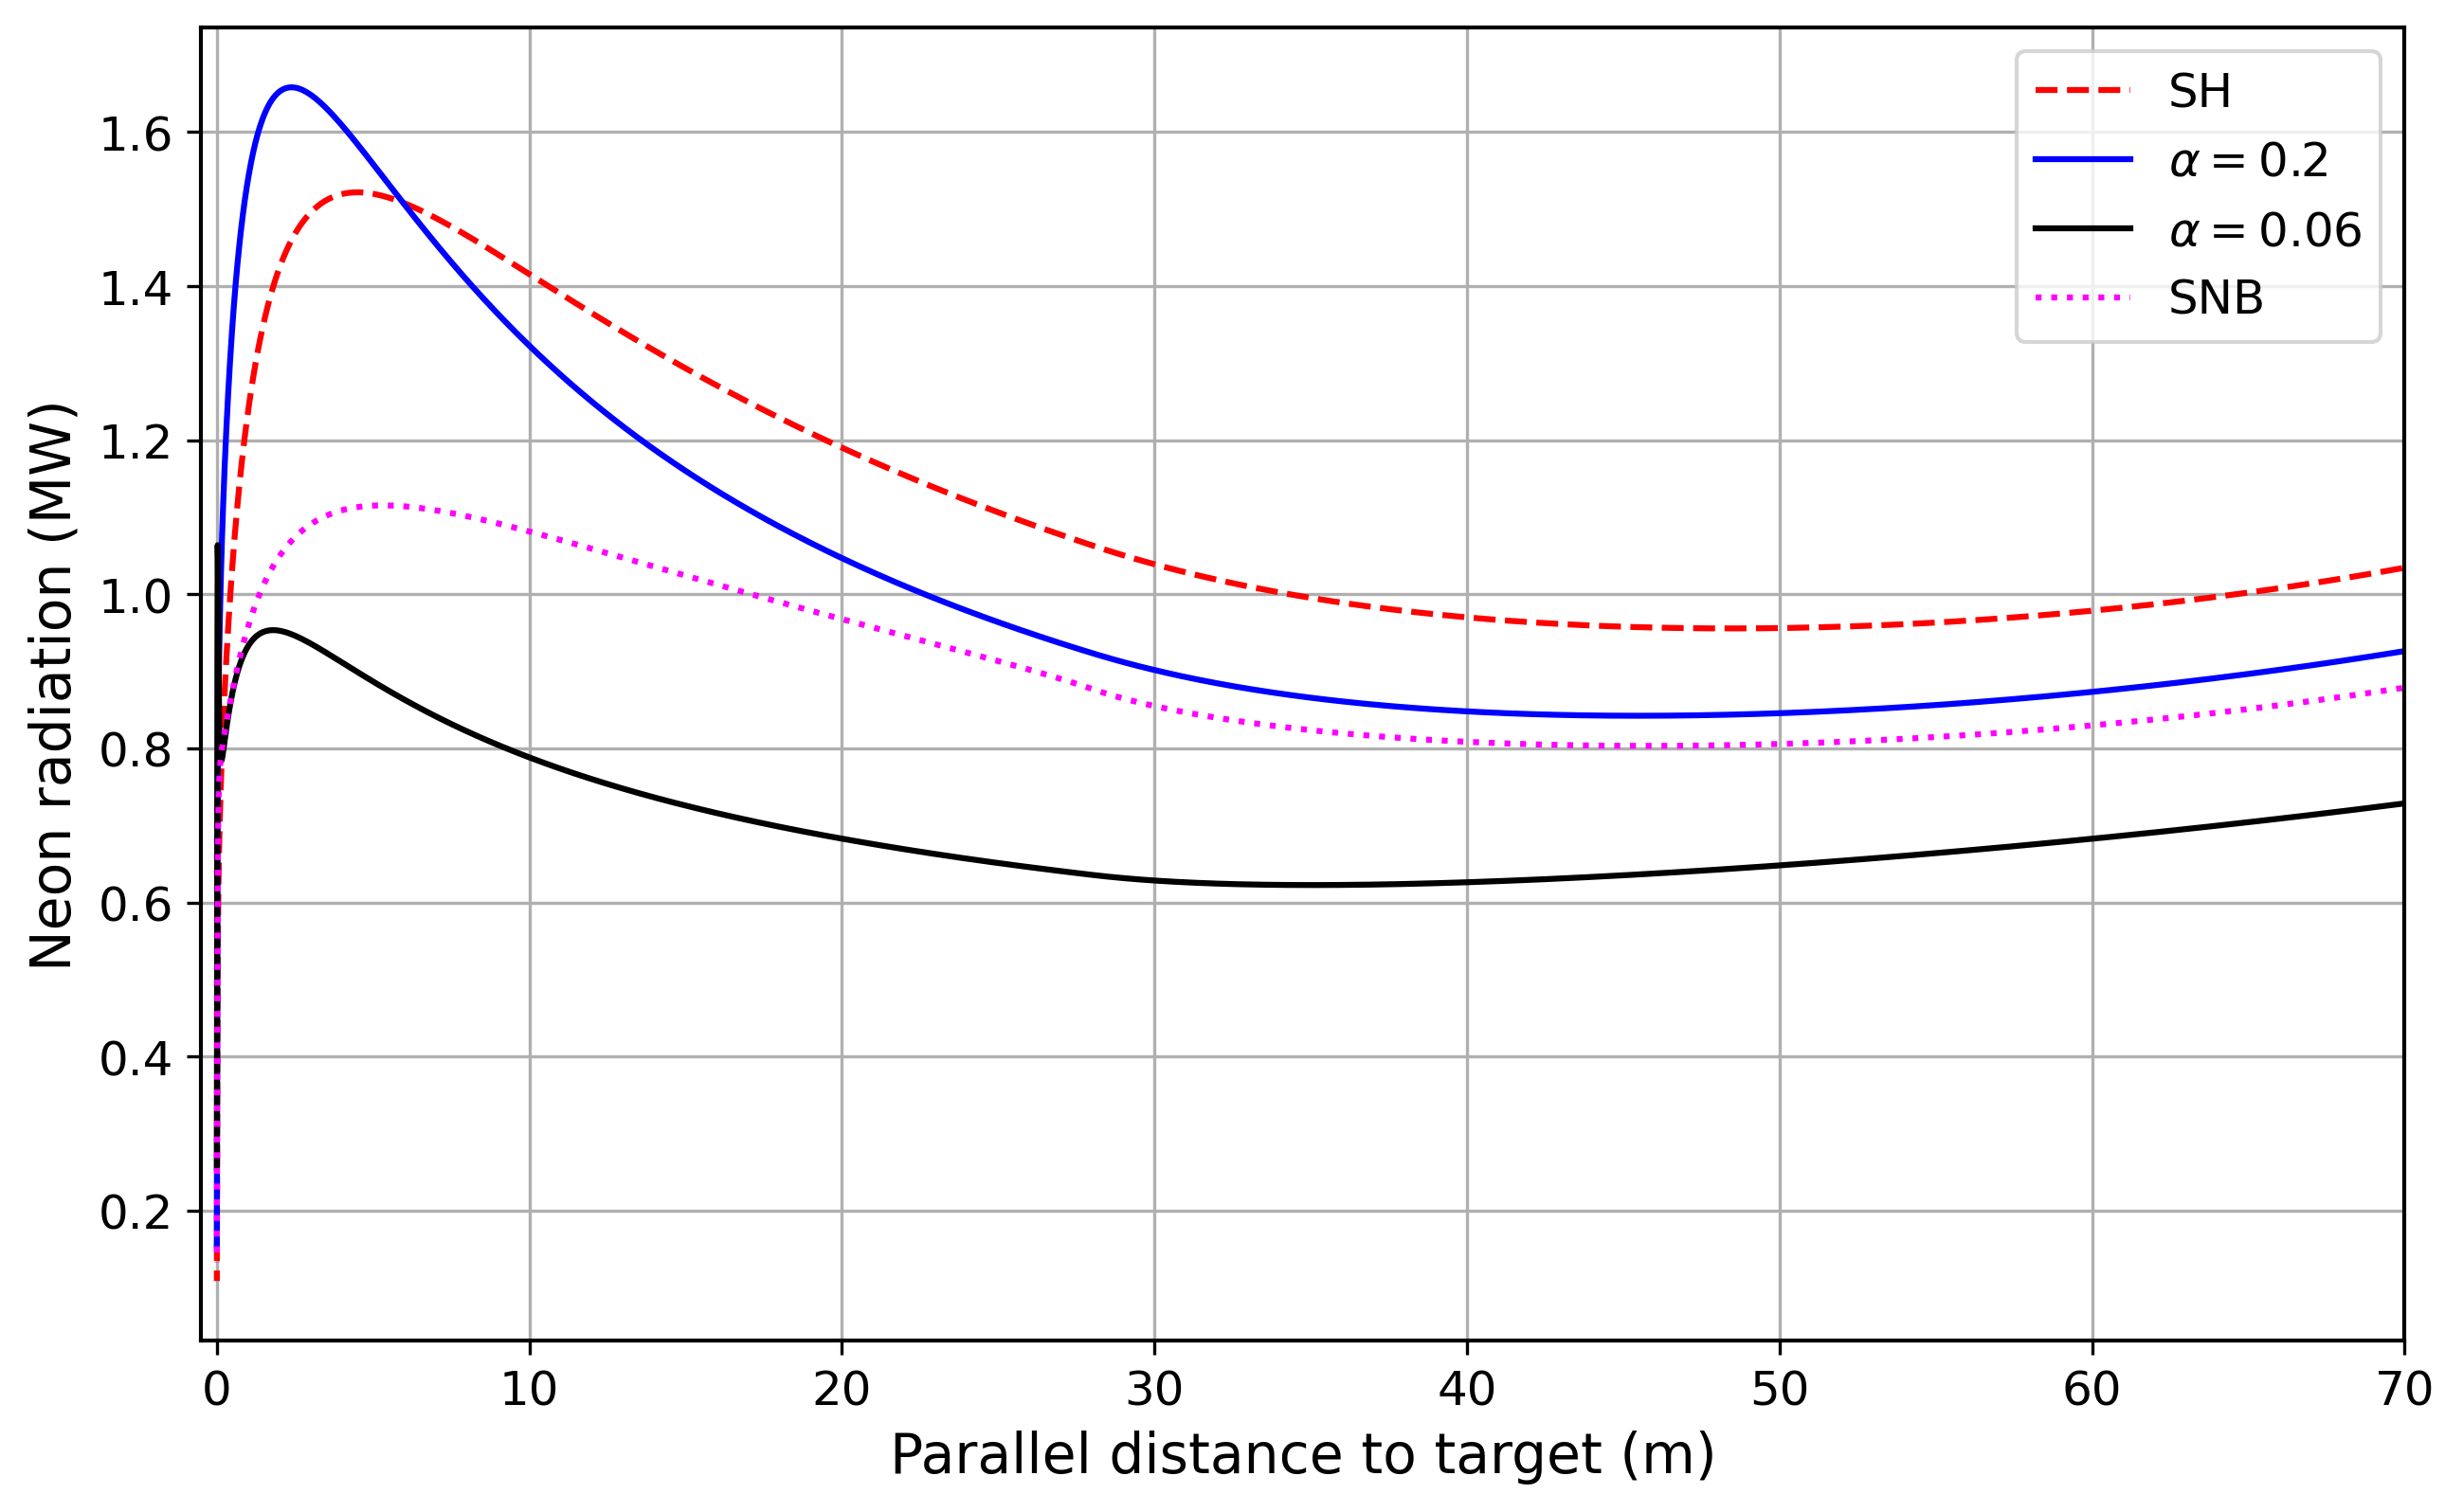

In [25]:
neon = 0.03

fig,ax = plt.subplots(1, 1, figsize=(10, 6), dpi=300)
for i in alpha_vals:
    if i == -1:
        linestyle = '--'
        color = 'red'
        label = 'SH'
    elif i == 0.2:
        linestyle = '-'
        color = 'blue'
        label = r'$\alpha = 0.2$'
    elif i == 0.06:
        linestyle = '-'
        color = 'black'
        label = r'$\alpha = 0.06$'
    elif i == 'snb':
        linestyle = ':'
        color = 'magenta'
        label = 'SNB'



    # for j in neon_vals:
    param = replace_guards(cs[f'alpha_{i}_neon_{neon}'].ds.isel(t=-1)['Rneon'].values) * replace_guards(cs[f'alpha_{i}_neon_{neon}'].ds.isel(t=-1)['dv'].values) #* replace_guards(cs[f'alpha_{i}_neon_{neon}'].ds.isel(t=-1)['Vd+'].values)
    yflipped = (np.max(y) - y)
    ax.plot((yflipped)[1:], (param*-1e-6)[1:], linestyle=linestyle, color=color, label=f'{label}')
    ax.legend()
    ax.set_xlabel('Parallel distance to target (m)')
    ax.set_ylabel('Neon radiation (MW)')
    ax.set_xbound(-0.5, 70)
    # fig.legend(ncols = 4)
    # ax.p
    # ax.set_xscale('log')]
    # ax.set_yscale('log')

# Collisionality calc Fig 7

Model: SH, Neon: 3.0% - Lengths: y_flipped=802, Te=802, Ne=802
Model: SNB, Neon: 3.0% - Lengths: y_flipped=802, Te=802, Ne=802
Model: SH, Neon: 4.0% - Lengths: y_flipped=802, Te=802, Ne=802
Model: SNB, Neon: 4.0% - Lengths: y_flipped=802, Te=802, Ne=802


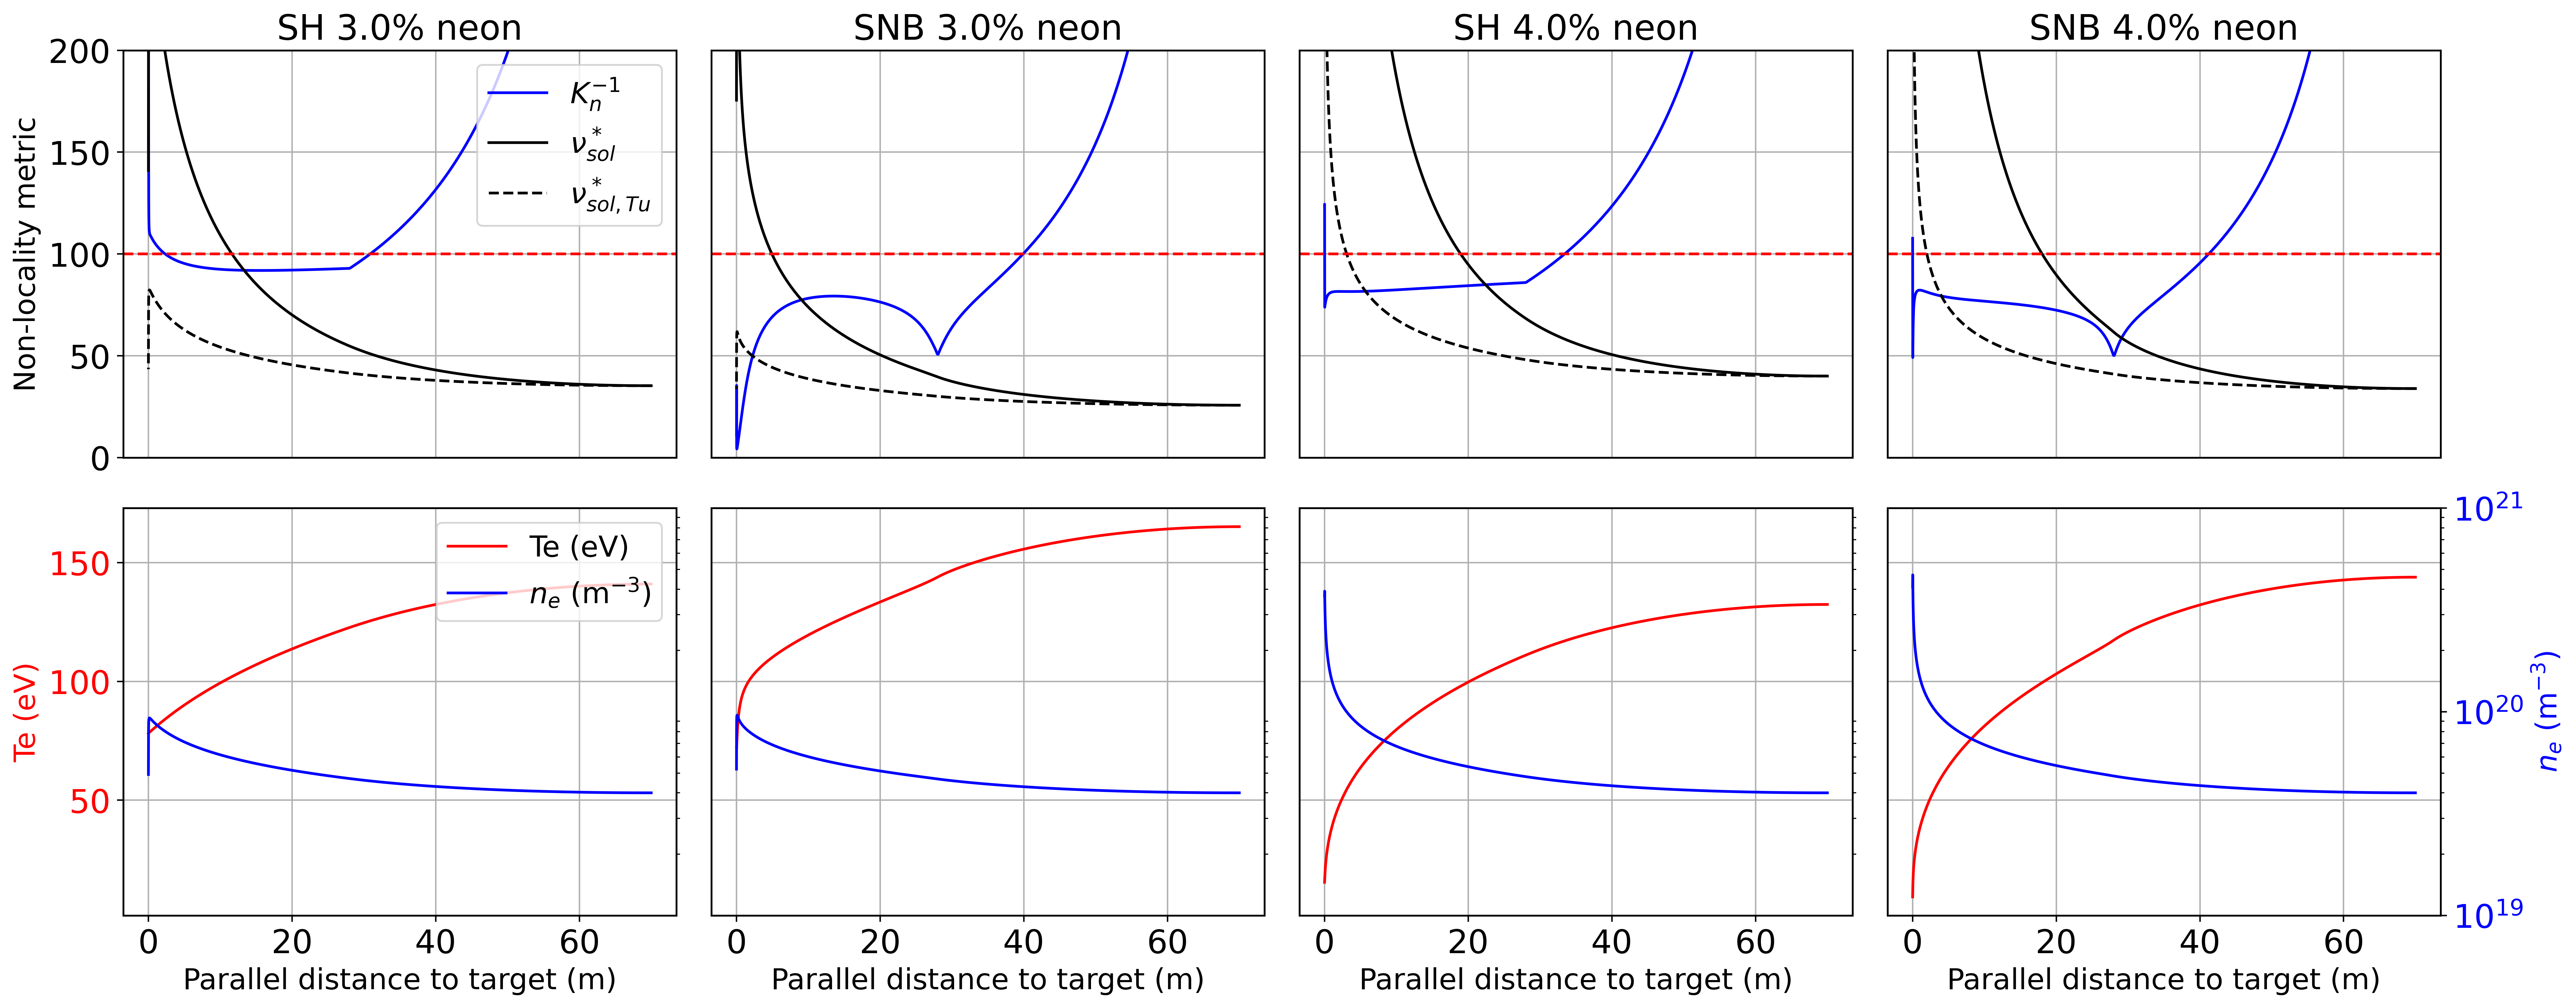

In [26]:
# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 10

# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})

import numpy as np
import matplotlib.pyplot as plt

# Select specific neon values and models
neon_vals = [0.03, 0.04]
models = ['-1', 'snb']  # SH and SNB models
model_names = ['SH', 'SNB']

# Create figure with 2x4 subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 8), dpi=500)

# Share y-axes within rows
# Top row (non-locality metrics)
for col in range(1, 4):
    axes[0, col].sharey(axes[0, 0])
# Bottom row (temperature) - we'll handle density separately
for col in range(1, 4):
    axes[1, col].sharey(axes[1, 0])

# Create twin axes for density (bottom row)
density_axes = []
for col in range(4):
    ax_ne = axes[1, col].twinx()
    density_axes.append(ax_ne)
    if col > 0:
        ax_ne.sharey(density_axes[0])

# Loop through models and neon concentrations
col_idx = 0
for neon_idx, neon_conc in enumerate(neon_vals):
    for model_idx, model in enumerate(models):
        j = model
        
        # Determine title based on model
        if j == '-1':
            model_title = 'SH'
        elif j == 'snb':
            model_title = 'SNB'
        else:
            model_title = f'α = {j}'
        
        # Get data
        Te = replace_guards(cs[f'alpha_{j}_neon_{neon_conc}'].ds.isel(t=-1)['Te'])
        y = cs[f'alpha_{j}_neon_{neon_conc}'].ds.isel(t=-1)['pos'].values[2:-2]
        Ne = replace_guards(cs[f'alpha_{j}_neon_{neon_conc}'].ds.isel(t=-1)['Ne'])

        # Calculate non-locality metrics
        lambda_ee = ((Te**2) * 10**(16) / Ne) / np.sqrt(2*np.pi)
        Ls = np.max(cs[f'alpha_{j}_neon_{neon_conc}'].ds.isel(t=-1)['pos'].values[2:-2])

        y_flipped = (cs[f'alpha_{j}_neon_{neon_conc}'].ds.isel(t=-1)['pos'].values[1:-1].max() - cs[f'alpha_{j}_neon_{neon_conc}'].ds.isel(t=-1)['pos'].values[1:-1])

        print(f"Model: {model_title}, Neon: {neon_conc*100}% - Lengths: y_flipped={len(y_flipped)}, Te={len(Te)}, Ne={len(Ne)}")

        grad_T = np.gradient(Te, y_flipped)
        Lt = np.abs(Te/grad_T)

        lt_over_lambda = (Lt/lambda_ee)
        ls_over_lambda = (Ls/lambda_ee)

        # using constant upstream temperature
        lambda_ee_const = ((Te[2]**2) * 10**(16) / Ne) / np.sqrt(2*np.pi)
        lt_over_lambda_const = (Lt/lambda_ee_const)
        ls_over_lambda_const = (Ls/lambda_ee_const)

        # Get current axes
        ax_top = axes[0, col_idx]
        ax_temp = axes[1, col_idx]
        ax_ne = density_axes[col_idx]

        # Top row - Non-locality metrics
        ax_top.plot(y_flipped, lt_over_lambda, '-', color='blue', label=r'$K_n^{-1}$')
        ax_top.plot(y_flipped, ls_over_lambda, '-', color='black', label=r'$\nu_{sol}^*$')
        ax_top.plot(y_flipped, ls_over_lambda_const, '--', color='black', label=r'$\nu_{sol, Tu}^*$')
        ax_top.axhline(100, color='red', linestyle='--')

        ax_top.set_ylim(0, 200)
        ax_top.set_title(f'{model_title} {neon_conc*100}% neon')
        
        # Remove x-axis ticks and labels for top plots
        ax_top.set_xticklabels([])
        ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        
        # Y-label only on leftmost plot
        if col_idx == 0:
            ax_top.set_ylabel('Non-locality metric')
            ax_top.legend(loc='upper right')
        else:
            ax_top.tick_params(axis='y', left=False, labelleft=False)

        # Bottom row - Temperature and density profiles
        ax_temp.plot(y_flipped, Te, '-', color='red', label='Te (eV)')
        ax_ne.plot(y_flipped, Ne, '-', color='blue', label=r'$n_e$ (m$^{-3}$)')

        # Set density axis to log scale
        ax_ne.set_yscale('log')
        ax_ne.set_ybound(1e19, 1e21)
        ax_ne.grid(False)
        
        # Set colors and labels
        if col_idx == 0:
            ax_temp.set_ylabel('Te (eV)', color='red')
            ax_temp.tick_params(axis='y', labelcolor='red')
            # Remove secondary y-axis ticks for leftmost
            ax_ne.tick_params(axis='y', right=False, labelright=False)
        elif col_idx == 3:  # Rightmost plot
            ax_ne.set_ylabel(r'$n_e$ (m$^{-3}$)', color='blue')
            ax_ne.tick_params(axis='y', labelcolor='blue')
            # Remove primary y-axis ticks for rightmost
            ax_temp.tick_params(axis='y', left=False, labelleft=False)
        else:  # Middle plots
            # Remove both primary and secondary y-axis ticks
            ax_temp.tick_params(axis='y', left=False, labelleft=False)
            ax_ne.tick_params(axis='y', right=False, labelright=False)
        
        # Set x-labels on bottom plots
        ax_temp.set_xlabel('Parallel distance to target (m)')
        
        # Legend only on first subplot
        if col_idx == 0:
            lines1, labels1 = ax_temp.get_legend_handles_labels()
            lines2, labels2 = ax_ne.get_legend_handles_labels()
            ax_temp.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

        col_idx += 1

plt.tight_layout()
plt.savefig('neon_SH_SNB_comparison.svg', format='svg')
plt.savefig('neon_SH_SNB_comparison.png', format='png', dpi=500)
plt.show()